

# Monte Carlo Simulation Non Parametric
### OPIM 5641 — Business Decision Modeling · Module1

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/drdave-teaching/OPIM5641-notebooks/blob/main/Module1/MonteCarloSimulation_NonParametric.ipynb)

*Run me top to bottom — **Runtime → Run all**. Data loads from a stable link, so there's nothing to upload.*

# Nonparametric Monte Carlo simulation
--------------------------
**Dr. Dave Wanik - OPIM 5641: Business Decision Modeling - University of Connecticut**

This is a nice approach - rather than sampling from the distribution, we can sample from the dataframe itself.

This is not my original work - but I have customized it for class and made it a little easier to digest (I used a random number generator to make my own data): https://towardsdatascience.com/intro-to-monte-carlo-simulations-using-business-examples-794fae76e832



In [ ]:
import pandas as pd
import numpy as np
from pylab import *

## Problem description: managing a subscription service
Suppose you are running an online subscription-based service like Spotify. You want to set aside enough cash today to ensure, **with 99% confidence**, that you will have at least 1 million USD to pay for your annual costs of maintaining the service next year.

We assume:
* The subscription fee is 10 USD per month per user and can be cancelled any month
* You have 10,000 users. Your monthly recurring revenue MRR is 10,000 users x 10 USD/user = 100,000 USD.
* Your annual cost of maintaining the service is fixed at 1,000,000 USD per year regardless of users
* Below shows the monthly net growth in the % of users over the past 60 months which could be negative if churn exceeds growth. Note that these numbers are different than the TowardsDataScience article. For the sake of simplicity, there is no seasonality and you expect the coming 12 months over the next year to be similar to any of the previous 60 months.

In [ ]:
# let's download the data!
#https://drive.google.com/file/d/1G6NhiKlTIRSk5_3PlABu1RNR2QJTtKEZ/view?usp=sharing
!gdown --id 1G6NhiKlTIRSk5_3PlABu1RNR2QJTtKEZ # see how this downloaded locally to your runtime?

/usr/local/lib/python3.10/dist-packages/gdown/cli.py:138: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1G6NhiKlTIRSk5_3PlABu1RNR2QJTtKEZ
To: /content/Mock_SubscriptionData.csv
100% 578/578 [00:00<00:00, 1.28MB/s]


When we read the data, we see have indeed have monthly sales from 1 to 60 months.

In [ ]:
# read the data
df = pd.read_csv('Mock_SubscriptionData.csv')
df

,Month,NetGrowth
0,1,-8.64
1,2,4.86
2,3,-0.27
3,4,12.30
4,5,-0.66
5,6,11.52
6,7,11.82
7,8,-2.09
8,9,4.86
9,10,8.48


First thing to do is explore the data and see what it looks like.

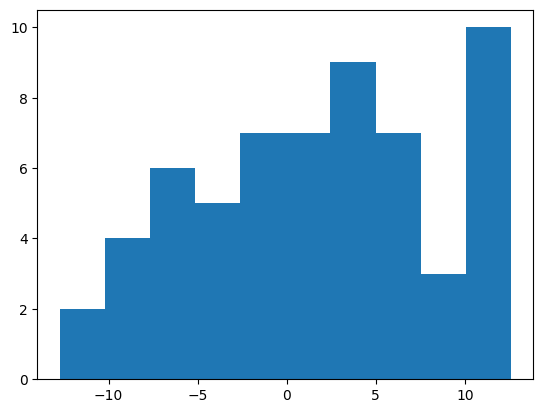

In [ ]:
hist(df['NetGrowth'])
plt.show()

...any guesses on distribution? Kind of looks triangular but also might be bimodal... could be a little bit uniform... what to do?!

# Sample directly from the distribution
When in doubt, sample directly from the distribution. What we can do in this case is simulate scenarios of what the next 12 months could look like based on the available history. Rather than sampling from a distribution (like the triangular distribution) we are sampling directly from the historical data.

How to sample from a pandas dataframe:
* https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.sample.html

Click through! And note the argument for `replace=False` which is the default. This means NO REPLACEMENT SAMPLING (in a sample of 12 rows, you can't pull the same row twice.) If `replace=True', this means you could hypothetically pull one row 12 times! Both are OK - as modeler, you get to decide what makes sense. In small data problems, folks will opt to sample with replacement to 'stretch' their dataset.

## Without replacement

In [ ]:
# let's make 12 random draws from the column, this will be a dummy 12 months that COULD happen
# you are effectively saying that history repeats itself

df['NetGrowth'].sample(n=12, replace='False') # without replacement



46     5.79
11    -4.96
36     7.41
1      4.86
5     11.52
16     4.59
10    -3.18
45     4.13
41     6.37
29     8.40
30    -9.39
4     -0.66
Name: NetGrowth, dtype: float64

## With replacement

In [ ]:
df['NetGrowth'].sample(n=12, replace='True') # with replacement
# did you pull the same row twice? it's OK if you did!

17    11.35
16     4.59
58     8.02
40    -7.18
27    11.34
6     11.82
6     11.82
15    -4.80
23    -4.74
14    -6.01
17    11.35
10    -3.18
Name: NetGrowth, dtype: float64

Here's how to do it with numpy...
* https://numpy.org/doc/stable/reference/random/generated/numpy.random.choice.html

Different arguments, same functionality.

In [ ]:
NetGrowth = np.array(df['NetGrowth'])
np.random.choice(a=NetGrowth, size=12, replace='True') # numpy arrays are 'simpler' than pandas dataframes or series
                                                      # and are easier to manipulate

array([-7.490e+00, -1.273e+01,  1.258e+01,  1.000e-02,  7.410e+00,
        1.135e+01, -1.390e+00, -8.640e+00,  7.410e+00,  6.490e+00,
        3.710e+00,  1.980e+00])

# So... how much money do we need to set aside?
... in order to ensure we will be able to cover the 1M operating costs at the end of the year.

This means calculate the revenue from our users and identify if we will have a shortfall or not.

It's always good to practice and see what ONE iteration looks like, that way you know you did it right.

In [ ]:
# simulate total revenue for one year
# let's work within a pandas dataframe
tmp = pd.DataFrame(columns=('Month', 'NetGrowth', 'Users', 'Revenue (Users x 10USD)'))
tmp

,Month,NetGrowth,Users,Revenue (Users x 10USD)


Now fill it in! Starting with the month. `np.arange(start, end, unit)` where end point is NOT included!

In [ ]:
# now fill it in!
tmp['Month'] = np.arange(1,13,1)
tmp # :) looks good

,Month,NetGrowth,Users,Revenue (Users x 10USD)
0,1,NaN,NaN,NaN
1,2,NaN,NaN,NaN
2,3,NaN,NaN,NaN
3,4,NaN,NaN,NaN
4,5,NaN,NaN,NaN
5,6,NaN,NaN,NaN
6,7,NaN,NaN,NaN
7,8,NaN,NaN,NaN
8,9,NaN,NaN,NaN
9,10,NaN,NaN,NaN


In [ ]:
# let's fill in NetGrowth - first value will be a constant
tmp['NetGrowth'] = np.random.choice(a=NetGrowth, size=12, replace='True')
tmp

,Month,NetGrowth,Users,Revenue (Users x 10USD)
0,1,8.40,NaN,NaN
1,2,-8.22,NaN,NaN
2,3,-10.86,NaN,NaN
3,4,-0.27,NaN,NaN
4,5,-8.22,NaN,NaN
5,6,-8.64,NaN,NaN
6,7,6.37,NaN,NaN
7,8,-7.18,NaN,NaN
8,9,10.68,NaN,NaN
9,10,-12.73,NaN,NaN


Now this is where it gets tricky. At the top of the year, you will always have 10,000 subscribers. So let's make a variable for this constant and then adjust.

In [ ]:
initialUsers = 10000 # it's a good idea not to hardcode things in your scripts
initialUsers

# the numbers will always change here, but you should see the number of users
# change by the NetGrowth column
for a in np.arange(1,13,1):
  print(a)
  if a == 1:
    tmp.loc[tmp['Month']==a, 'Users'] = initialUsers+initialUsers*tmp.loc[tmp['Month']==a, 'NetGrowth']/100 # because it's a percentage!
  else:
    previousUsers = np.array(tmp.loc[tmp['Month']==a-1, 'Users']) # i had an error with pandas here - converting to arrays helped!
    tmp.loc[tmp['Month']==a, 'Users'] = previousUsers+previousUsers*tmp.loc[tmp['Month']==a, 'NetGrowth']/100 # because it's a percentage!

# check your work
tmp

1
2
3
4
5
6
7
8
9
10
11
12


,Month,NetGrowth,Users,Revenue (Users x 10USD)
0,1,8.40,10840.0,NaN
1,2,-8.22,9948.952,NaN
2,3,-10.86,8868.495813,NaN
3,4,-0.27,8844.550874,NaN
4,5,-8.22,8117.528792,NaN
5,6,-8.64,7416.174305,NaN
6,7,6.37,7888.584608,NaN
7,8,-7.18,7322.184233,NaN
8,9,10.68,8104.193509,NaN
9,10,-12.73,7072.529675,NaN


In [ ]:
# now build out the revenue
tmp['Revenue (Users x 10USD)'] = tmp['Users']*10
tmp

,Month,NetGrowth,Users,Revenue (Users x 10USD)
0,1,8.40,10840.0,108400.0
1,2,-8.22,9948.952,99489.52
2,3,-10.86,8868.495813,88684.958128
3,4,-0.27,8844.550874,88445.508741
4,5,-8.22,8117.528792,81175.287923
5,6,-8.64,7416.174305,74161.743046
6,7,6.37,7888.584608,78885.846078
7,8,-7.18,7322.184233,73221.84233
8,9,10.68,8104.193509,81041.93509
9,10,-12.73,7072.529675,70725.296753


Now sum it all up and you have the revenue for the year!

In [ ]:
np.sum(tmp['Revenue (Users x 10USD)'])

989765.4025478248

# A big for loop
Now take everything you've done and make a big for loop.

Copy/paste, tab it over, and make sure you make a place to store your results. Remember, print statement can REALLY slow down your script. For loops can be slow, but this was the easiest way I thought I could present the content.

In [ ]:
# an empty place to store results
resultDF = []

for x in np.arange(0,1000,1):
  initialUsers = 10000 # it's a good idea not to hardcode things in your scripts
  initialUsers

  # simulate total revenue for one year
  # let's work within a pandas dataframe
  tmp = pd.DataFrame(columns=('Month', 'NetGrowth', 'Users', 'Revenue (Users x 10USD)'))
  tmp

  # now fill it in!
  tmp['Month'] = np.arange(1,13,1)
  tmp # :) looks good

  # let's fill in NetGrowth - first value will be a constant
  tmp['NetGrowth'] = np.random.choice(a=NetGrowth, size=12, replace='True')
  tmp

  # the numbers will always change here, but you should see the number of users
  # change by the NetGrowth column
  for a in np.arange(1,13,1):
    if a == 1:
      tmp.loc[tmp['Month']==a, 'Users'] = initialUsers+initialUsers*tmp.loc[tmp['Month']==a, 'NetGrowth']/100 # because it's a percentage!
    else:
      previousUsers = np.array(tmp.loc[tmp['Month']==a-1, 'Users']) # i had an error with pandas here - converting to arrays helped!
      tmp.loc[tmp['Month']==a, 'Users'] = previousUsers+previousUsers*tmp.loc[tmp['Month']==a, 'NetGrowth']/100 # because it's a percentage!

  # now build out the revenue
  tmp['Revenue (Users x 10USD)'] = tmp['Users']*10
  tmp

  # now sum!
  tmpRevenue = np.sum(tmp['Revenue (Users x 10USD)'])
  # now store!
  resultDF.append(tmpRevenue)

In [ ]:
# what does resultDF look like?
resultDF

[1302738.4245416261,
 1129442.834334661,
 1221961.585360408,
 1582824.9443773746,
 1415106.0687114089,
 1301141.0800789958,
 1463815.531090039,
 1485353.5409919582,
 1183747.2513966484,
 1137823.1762865754,
 1268413.0728000968,
 1642948.008031942,
 1593173.6163094195,
 1275513.4648899375,
 1058631.2514134867,
 1304934.0770238906,
 1362195.4517513302,
 1290478.4940082566,
 1340959.6039964205,
 1156634.1343846326,
 1130968.3354358051,
 1253859.5475264064,
 1326165.434163548,
 1476339.5559382972,
 1214589.1138623022,
 1577121.034831181,
 1263201.843352898,
 1360007.9717945876,
 1508129.6255060686,
 1274942.7525251007,
 1690351.9564459494,
 1091630.2186691673,
 1171579.4038627814,
 1533764.2651832916,
 991114.3532058772,
 1596958.1186313375,
 922887.2036582135,
 1148144.6875558256,
 1310023.8995473876,
 1172968.6089282613,
 1370811.629202862,
 1503728.539873185,
 1375667.4448866856,
 1458526.1305173538,
 1371662.7006977838,
 1064370.8540163334,
 1650501.4599339054,
 1242651.3667143432,
 12

So how much revenue will we make next year?

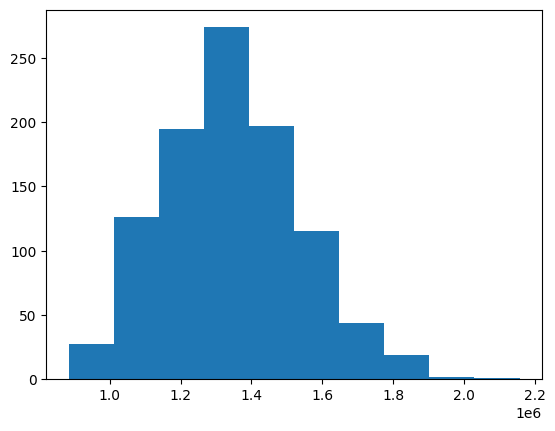

In [ ]:
hist(resultDF)
show()

# Risk Analysis

Now you can sort the output and get the probability of being less than X.

In [ ]:
# how many are less than zero?
resultDF = np.array(resultDF)
lessThan1M = np.where(resultDF <= 1000000)
print(np.shape(lessThan1M))

(1, 25)


In [ ]:
# here are the records that are less than 1M
# you can count them!
lessThan1M

(array([ 34,  36, 112, 122, 133, 186, 249, 259, 269, 307, 342, 346, 433,
        517, 540, 559, 583, 666, 750, 782, 826, 850, 940, 947, 977]),)

In [ ]:
# this is the shape of the original dataframe
np.shape(resultDF)[0]

1000

10% of 1000 is 100, 1% is 10 records.

In [ ]:
# so, it's less than zero divided by total (10K)
print(np.shape(lessThan1M)[1]/np.shape(resultDF)[0])

0.025


# Conclusions
 This means there is a chance we won't make at least 1M dollars. How much do we need to reserve in order to be 99% sure we will have enough money?

In [ ]:
# find 1% rows after the minimum
resultDF = np.sort(resultDF)
resultDF[0:10]

array([884004.38966051, 893101.40185194, 920311.76606016, 922887.20365821,
       934830.49283974, 951986.97738247, 953682.11934533, 956089.43579001,
       959625.38238158, 964140.70930041])

What's the max of this array?

In [ ]:
np.max(resultDF[0:10])

964140.7093004056

Now subtract that from 1 million... that's the amount you need to reserve to cover your costs!

In [ ]:
1E6 - np.max(resultDF[0:10])

35859.29069959442

Keep in mind, your results will change.

# On Your Own
Can you try to incorporate a parametric distribution into this framework? Try to come up with a model for this news story: https://www.cnn.com/2022/01/26/entertainment/neil-young-spotify/index.html

Would it be a one-time shock to the system, or would it be sustained? How does this affect profitability?

Or, instead of just bootstrapping your raw data, why not add a little Gaussian noise (mean = 0, sd = 1)? How does this affect your answer?

Or, maybe you just want to use the last two years of data instead of the last five years of data - how does this affect profitability?

Even though we will all get different answers, when repeated 1000x, they should be close.

<center>

![spotify](https://upload.wikimedia.org/wikipedia/commons/thumb/b/bc/Antu_spotify.svg/512px-Antu_spotify.svg.png)